In [1]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob as glob
import os
import random
import seaborn as sns



In [2]:
ROOT_DIR = r"C:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\dataset"

VARIETIES = ["Spunta", "Rudolph", "Mondial", "Fontane"]

CHANNELS = ['R', 'G', 'B', 'H', 'S', 'V']

In [3]:
# DATA_DIR = r"C:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\dataset\Spunta\leaf_images\RGBFilter\channels_pgm"



# Map parts of filenames to classes
CLASS_MAP = {
    'healthybox': 'healthy',
    'unhealthybox': 'unhealthy',
    'unhealthy_boxes_bladroll': 'bladroll'
}

def get_label_from_filename(filename):
    filename_lower = filename.lower()
    # Order matters: longer/more specific substrings first
    for key in sorted(CLASS_MAP.keys(), key=lambda x: -len(x)):
        if key in filename_lower:
            return CLASS_MAP[key]
    return 'unknown'



In [4]:
def load_channel_images(variety, channel_prefix):
    """
    Loads all images for a potato variety and channel (R,G,B,H,S,V).
    No prints; returns images and labels.
    """
    data_dir = os.path.join(
        ROOT_DIR,
        variety,
        "leaf_images",
        "RGBFilter",
        "channels_pgm"
    )

    pattern = os.path.join(data_dir, f"*_{channel_prefix}patch_*.pgm")
    files = glob.glob(pattern)

    imgs, labels = [], []
    for f in files:
        img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        imgs.append(img)
        labels.append(get_label_from_filename(f))

    return imgs, labels

In [5]:
REP_CHANNEL = "R"  # representative channel for summary

print("\n==== CLASS DISTRIBUTION BY VARIETY (Using R Channel) ====\n")

for variety in VARIETIES:
    imgs, labels = load_channel_images(variety, REP_CHANNEL)
    
    # Class distribution
    class_counts = {lbl: labels.count(lbl) for lbl in sorted(set(labels))}
    print(f"\n--- {variety} ---")
    print("Class counts:", class_counts)
    
    # Image shape + pixel count
    print("Image shape + pixel count for first 10 images:")
    for i, img in enumerate(imgs[:10]):
        h, w = img.shape
        print(f"  Image {i+1}: shape = {img.shape}, total pixels = {img.size}")



==== CLASS DISTRIBUTION BY VARIETY (Using R Channel) ====


--- Spunta ---
Class counts: {'bladroll': 59, 'healthy': 3136, 'unhealthy': 733}
Image shape + pixel count for first 10 images:
  Image 1: shape = (159, 145), total pixels = 23055
  Image 2: shape = (133, 219), total pixels = 29127
  Image 3: shape = (172, 184), total pixels = 31648
  Image 4: shape = (130, 213), total pixels = 27690
  Image 5: shape = (179, 115), total pixels = 20585
  Image 6: shape = (133, 195), total pixels = 25935
  Image 7: shape = (165, 163), total pixels = 26895
  Image 8: shape = (114, 197), total pixels = 22458
  Image 9: shape = (152, 174), total pixels = 26448
  Image 10: shape = (153, 170), total pixels = 26010

--- Rudolph ---
Class counts: {'healthy': 4951, 'unhealthy': 543}
Image shape + pixel count for first 10 images:
  Image 1: shape = (205, 218), total pixels = 44690
  Image 2: shape = (205, 107), total pixels = 21935
  Image 3: shape = (206, 251), total pixels = 51706
  Image 4: shape = (

In [6]:
variety_label_map = {}
REP_CHANNEL = "R"

for variety in VARIETIES:
    _, labels = load_channel_images(variety, REP_CHANNEL)
    variety_label_map[variety] = labels

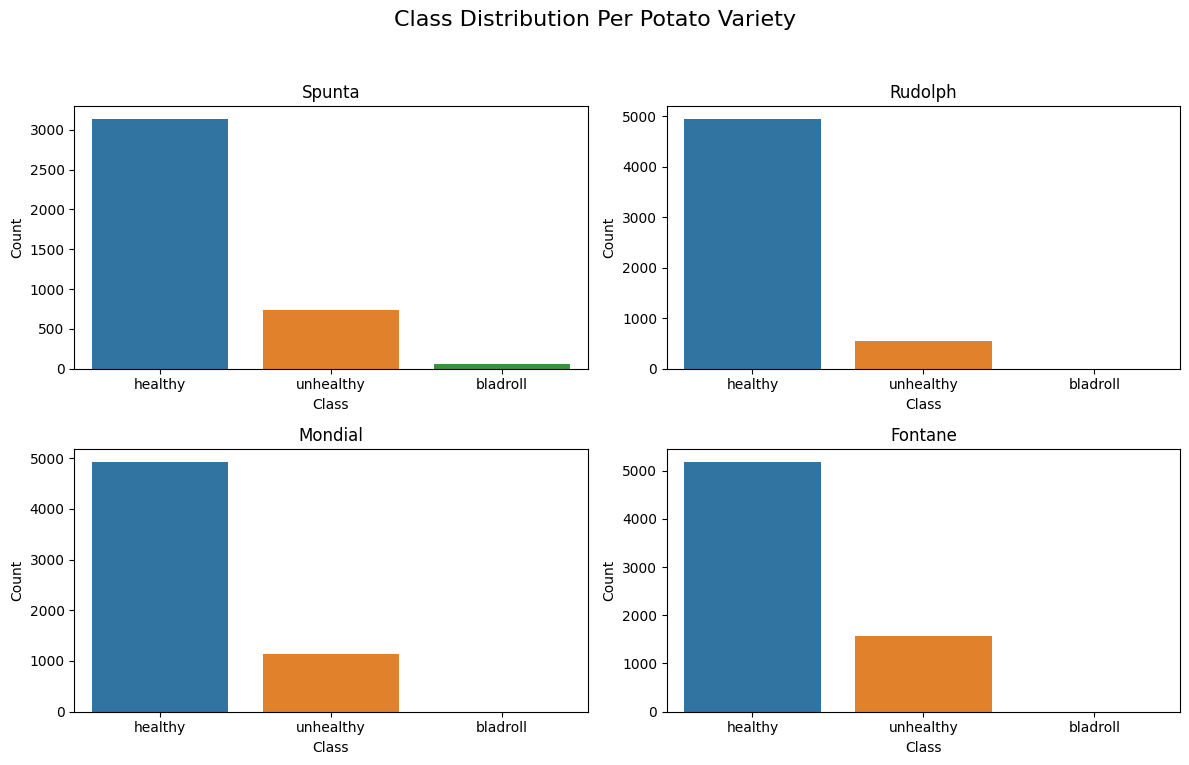

In [7]:
# ─────────────────────────────────────────────
# 1. PLOT PER-VARIETY DISTRIBUTIONS
# ─────────────────────────────────────────────

plt.figure(figsize=(12, 8))
plt.suptitle("Class Distribution Per Potato Variety", fontsize=16)

for i, variety in enumerate(VARIETIES):
    plt.subplot(2, 2, i + 1)
    sns.countplot(
        x=variety_label_map[variety],
        order=['healthy', 'unhealthy', 'bladroll']
    )
    plt.title(f"{variety}")
    plt.xlabel("Class")
    plt.ylabel("Count")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [8]:
# PIXEL_SAMPLE = 10000  # use all pixels

# for variety in VARIETIES:
#     print(f"\n========== Processing Variety: {variety} ==========\n")

#     # Load channel data
#     channel_data = {c: load_channel_images(variety, c) for c in CHANNELS}

#     # KDE grid
#     plt.figure(figsize=(18, 12))

#     for i, c in enumerate(CHANNELS):
#         imgs, labels = channel_data[c]
#         plt.subplot(2, 3, i + 1)

#         pixel_dict = {'healthy': [], 'unhealthy': []}

#         for img, lbl in zip(imgs, labels):
#             if lbl in pixel_dict:
#                 flat = img.flatten()
#                 n_sample = max(1, len(flat) // 100)  # Take 1% of pixels 
#                 sampled_pixels = np.random.choice(flat, n_sample, replace=False)
#                 pixel_dict[lbl].extend(sampled_pixels)

#         # Downsample only if PIXEL_SAMPLE is set
#         if PIXEL_SAMPLE is not None:
#             for lbl in pixel_dict:
#                 if len(pixel_dict[lbl]) > PIXEL_SAMPLE:
#                     pixel_dict[lbl] = random.sample(pixel_dict[lbl], PIXEL_SAMPLE)

#         # Draw KDE
#         for lbl, pixels in pixel_dict.items():
#             if len(pixels) > 0:
#                 sns.kdeplot(pixels, label=lbl, fill=True, alpha=0.3)

#         plt.title(f"{variety} - {c} channel")
#         plt.xlabel("Pixel intensity")
#         plt.ylabel("Density")
#         plt.legend()

#     plt.suptitle(f"KDE Pixel Intensity Distributions — {variety}", fontsize=16)
#     plt.tight_layout()
#     plt.show()



========== Processing Variety: Spunta ==========

[Spunta - R] Processed 50/3928 images for class 'healthy' (ETA: 4.3s)
[Spunta - R] Processed 100/3928 images for class 'healthy' (ETA: 3.8s)
[Spunta - R] Processed 150/3928 images for class 'healthy' (ETA: 3.5s)
[Spunta - R] Processed 200/3928 images for class 'healthy' (ETA: 3.5s)
[Spunta - R] Processed 250/3928 images for class 'healthy' (ETA: 3.3s)
[Spunta - R] Processed 300/3928 images for class 'unhealthy' (ETA: 3.2s)
[Spunta - R] Processed 350/3928 images for class 'healthy' (ETA: 3.1s)
[Spunta - R] Processed 400/3928 images for class 'unhealthy' (ETA: 3.0s)
[Spunta - R] Processed 450/3928 images for class 'healthy' (ETA: 3.0s)
[Spunta - R] Processed 500/3928 images for class 'healthy' (ETA: 3.0s)
[Spunta - R] Processed 550/3928 images for class 'healthy' (ETA: 2.8s)
[Spunta - R] Processed 600/3928 images for class 'healthy' (ETA: 2.8s)
[Spunta - R] Processed 650/3928 images for class 'healthy' (ETA: 2.8s)
[Spunta - R] Processed 

c:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


[Spunta - G] Processed 50/3928 images for class 'healthy' (ETA: 3.6s)
[Spunta - G] Processed 100/3928 images for class 'healthy' (ETA: 3.3s)
[Spunta - G] Processed 150/3928 images for class 'healthy' (ETA: 3.3s)
[Spunta - G] Processed 200/3928 images for class 'healthy' (ETA: 3.3s)
[Spunta - G] Processed 250/3928 images for class 'healthy' (ETA: 3.1s)
[Spunta - G] Processed 300/3928 images for class 'unhealthy' (ETA: 3.0s)
[Spunta - G] Processed 350/3928 images for class 'healthy' (ETA: 3.0s)
[Spunta - G] Processed 400/3928 images for class 'unhealthy' (ETA: 2.9s)
[Spunta - G] Processed 450/3928 images for class 'healthy' (ETA: 2.9s)
[Spunta - G] Processed 500/3928 images for class 'healthy' (ETA: 2.8s)
[Spunta - G] Processed 550/3928 images for class 'healthy' (ETA: 2.7s)
[Spunta - G] Processed 600/3928 images for class 'healthy' (ETA: 2.7s)
[Spunta - G] Processed 650/3928 images for class 'healthy' (ETA: 2.7s)
[Spunta - G] Processed 700/3928 images for class 'healthy' (ETA: 2.7s)
[Sp

c:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


[Spunta - B] Processed 50/3928 images for class 'healthy' (ETA: 3.5s)
[Spunta - B] Processed 100/3928 images for class 'healthy' (ETA: 3.2s)
[Spunta - B] Processed 150/3928 images for class 'healthy' (ETA: 3.0s)
[Spunta - B] Processed 200/3928 images for class 'healthy' (ETA: 3.1s)
[Spunta - B] Processed 250/3928 images for class 'healthy' (ETA: 2.9s)
[Spunta - B] Processed 300/3928 images for class 'unhealthy' (ETA: 2.9s)
[Spunta - B] Processed 350/3928 images for class 'healthy' (ETA: 2.8s)
[Spunta - B] Processed 400/3928 images for class 'unhealthy' (ETA: 2.8s)
[Spunta - B] Processed 450/3928 images for class 'healthy' (ETA: 2.7s)
[Spunta - B] Processed 500/3928 images for class 'healthy' (ETA: 2.7s)
[Spunta - B] Processed 550/3928 images for class 'healthy' (ETA: 2.5s)
[Spunta - B] Processed 600/3928 images for class 'healthy' (ETA: 2.5s)
[Spunta - B] Processed 650/3928 images for class 'healthy' (ETA: 2.6s)
[Spunta - B] Processed 700/3928 images for class 'healthy' (ETA: 2.6s)
[Sp

...

c:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


[Spunta - S] Processed 50/3928 images for class 'healthy' (ETA: 3.6s)
[Spunta - S] Processed 100/3928 images for class 'healthy' (ETA: 3.2s)
[Spunta - S] Processed 150/3928 images for class 'healthy' (ETA: 3.0s)
[Spunta - S] Processed 200/3928 images for class 'healthy' (ETA: 2.9s)
[Spunta - S] Processed 250/3928 images for class 'healthy' (ETA: 2.8s)
[Spunta - S] Processed 300/3928 images for class 'unhealthy' (ETA: 2.8s)
[Spunta - S] Processed 350/3928 images for class 'healthy' (ETA: 2.7s)
[Spunta - S] Processed 400/3928 images for class 'unhealthy' (ETA: 2.7s)
[Spunta - S] Processed 450/3928 images for class 'healthy' (ETA: 2.6s)
[Spunta - S] Processed 500/3928 images for class 'healthy' (ETA: 2.6s)
[Spunta - S] Processed 550/3928 images for class 'healthy' (ETA: 2.5s)
[Spunta - S] Processed 600/3928 images for class 'healthy' (ETA: 2.5s)
[Spunta - S] Processed 650/3928 images for class 'healthy' (ETA: 2.5s)
[Spunta - S] Processed 700/3928 images for class 'healthy' (ETA: 2.5s)
[Sp

c:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


[Spunta - V] Processed 50/3928 images for class 'healthy' (ETA: 3.6s)
[Spunta - V] Processed 100/3928 images for class 'healthy' (ETA: 3.3s)
[Spunta - V] Processed 150/3928 images for class 'healthy' (ETA: 3.1s)
[Spunta - V] Processed 200/3928 images for class 'healthy' (ETA: 3.2s)
[Spunta - V] Processed 250/3928 images for class 'healthy' (ETA: 3.0s)
[Spunta - V] Processed 300/3928 images for class 'unhealthy' (ETA: 2.9s)
[Spunta - V] Processed 350/3928 images for class 'healthy' (ETA: 2.8s)
[Spunta - V] Processed 400/3928 images for class 'unhealthy' (ETA: 2.8s)
[Spunta - V] Processed 450/3928 images for class 'healthy' (ETA: 2.8s)
[Spunta - V] Processed 500/3928 images for class 'healthy' (ETA: 2.7s)
[Spunta - V] Processed 550/3928 images for class 'healthy' (ETA: 2.6s)
[Spunta - V] Processed 600/3928 images for class 'healthy' (ETA: 2.6s)
[Spunta - V] Processed 650/3928 images for class 'healthy' (ETA: 2.6s)
[Spunta - V] Processed 700/3928 images for class 'healthy' (ETA: 2.6s)
[Sp

c:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


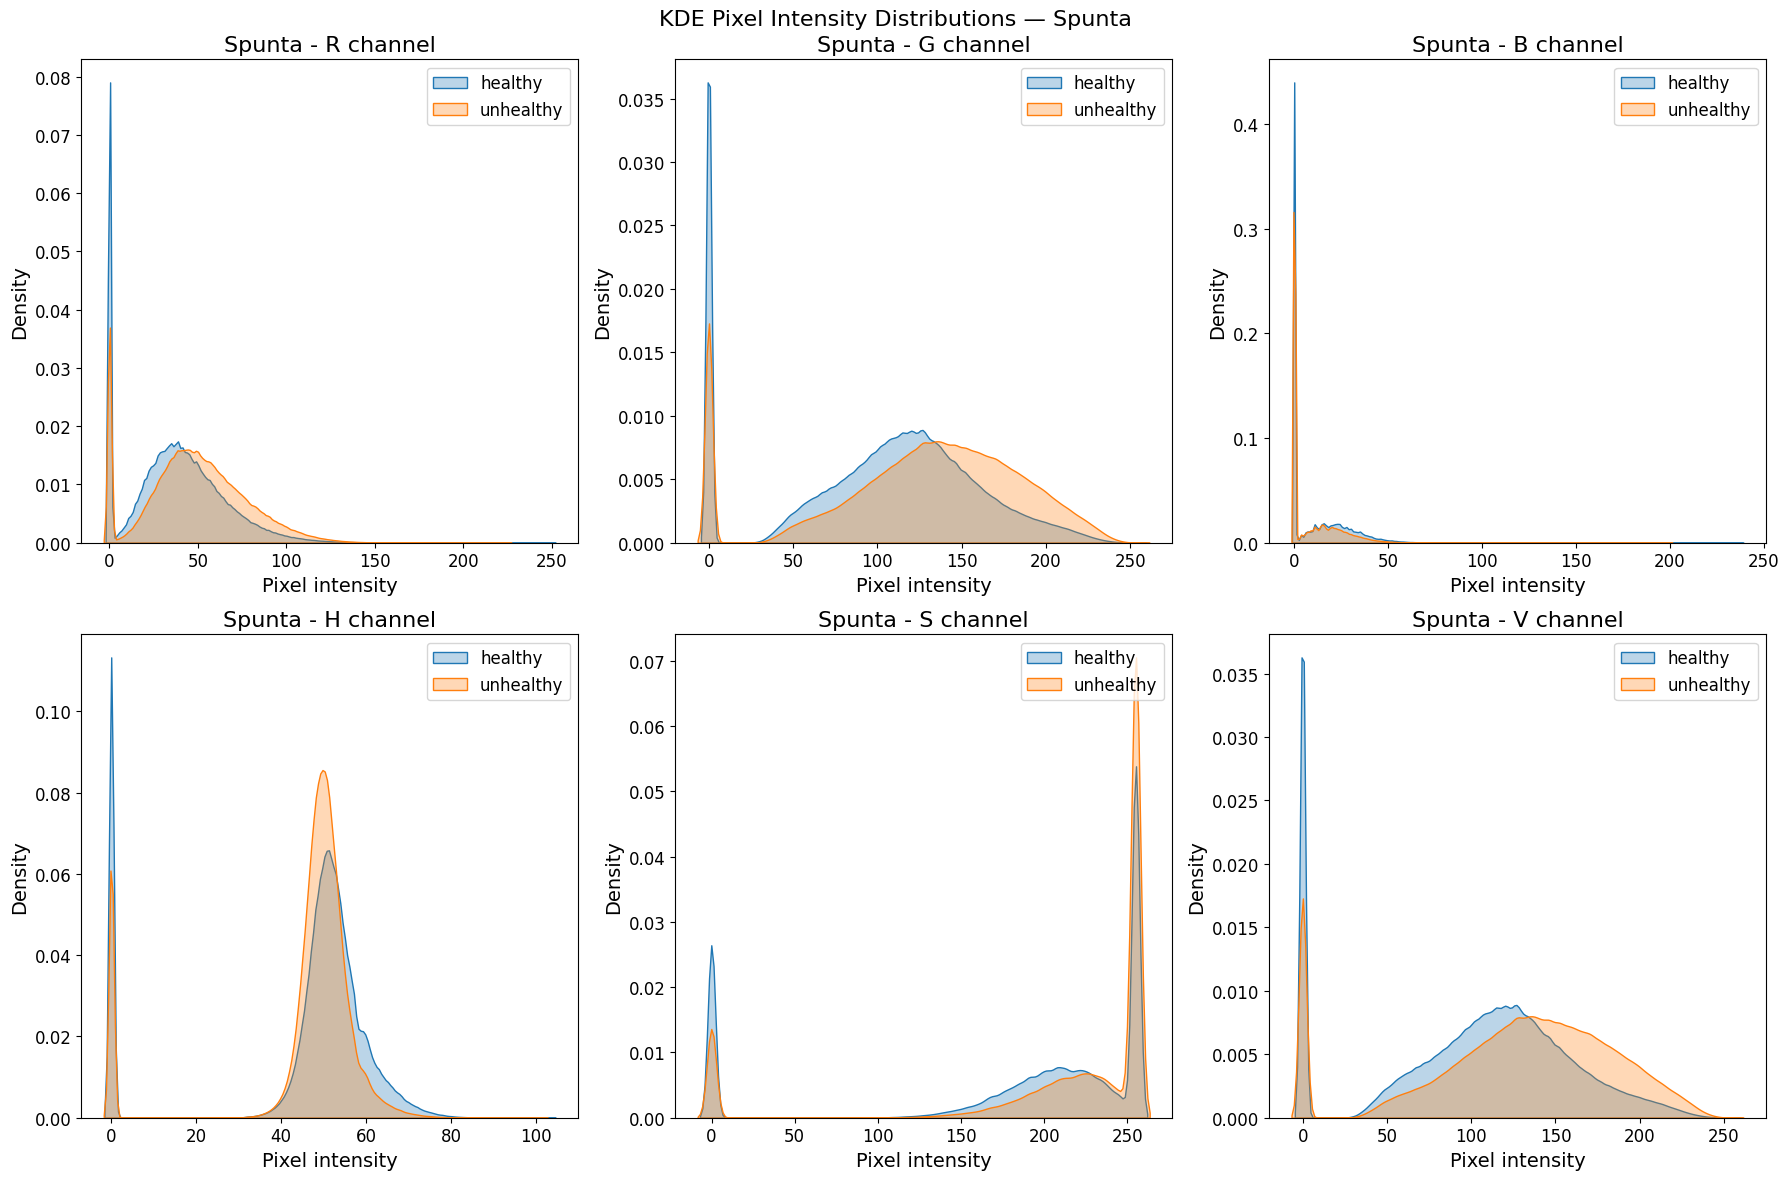


========== Processing Variety: Rudolph ==========

[Rudolph - R] Processed 50/5494 images for class 'healthy' (ETA: 5.2s)
[Rudolph - R] Processed 100/5494 images for class 'healthy' (ETA: 5.2s)
[Rudolph - R] Processed 150/5494 images for class 'healthy' (ETA: 4.8s)
[Rudolph - R] Processed 200/5494 images for class 'healthy' (ETA: 4.7s)
[Rudolph - R] Processed 250/5494 images for class 'healthy' (ETA: 5.0s)
[Rudolph - R] Processed 300/5494 images for class 'unhealthy' (ETA: 4.9s)
[Rudolph - R] Processed 350/5494 images for class 'healthy' (ETA: 5.0s)
[Rudolph - R] Processed 400/5494 images for class 'healthy' (ETA: 5.0s)
[Rudolph - R] Processed 450/5494 images for class 'healthy' (ETA: 5.0s)
[Rudolph - R] Processed 500/5494 images for class 'healthy' (ETA: 5.1s)
[Rudolph - R] Processed 550/5494 images for class 'healthy' (ETA: 5.4s)
[Rudolph - R] Processed 600/5494 images for class 'healthy' (ETA: 5.6s)
[Rudolph - R] Processed 650/5494 images for class 'unhealthy' (ETA: 5.8s)
[Rudolph 

c:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\polyx\Desktop\Github Repos\Pattern_spectra_ML\venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


[Rudolph - G] Processed 50/5494 images for class 'healthy' (ETA: 5.7s)
[Rudolph - G] Processed 100/5494 images for class 'healthy' (ETA: 5.6s)
[Rudolph - G] Processed 150/5494 images for class 'healthy' (ETA: 5.4s)
[Rudolph - G] Processed 200/5494 images for class 'healthy' (ETA: 5.0s)
[Rudolph - G] Processed 250/5494 images for class 'healthy' (ETA: 5.5s)
[Rudolph - G] Processed 300/5494 images for class 'unhealthy' (ETA: 5.4s)
[Rudolph - G] Processed 350/5494 images for class 'healthy' (ETA: 5.5s)
[Rudolph - G] Processed 400/5494 images for class 'healthy' (ETA: 5.4s)
[Rudolph - G] Processed 450/5494 images for class 'healthy' (ETA: 5.6s)
[Rudolph - G] Processed 500/5494 images for class 'healthy' (ETA: 5.8s)
[Rudolph - G] Processed 550/5494 images for class 'healthy' (ETA: 5.9s)
[Rudolph - G] Processed 600/5494 images for class 'healthy' (ETA: 6.1s)
[Rudolph - G] Processed 650/5494 images for class 'unhealthy' (ETA: 6.4s)
[Rudolph - G] Processed 700/5494 images for class 'healthy' (

In [ ]:
import time

PIXEL_SAMPLE = None  # Set to None to use all pixels per class

for variety in VARIETIES:
    print(f"\n========== Processing Variety: {variety} ==========\n")

    channel_data = {c: load_channel_images(variety, c) for c in CHANNELS}
    plt.figure(figsize=(18, 12))

    for i, c in enumerate(CHANNELS):
        imgs, labels = channel_data[c]
        plt.subplot(2, 3, i + 1)

        pixel_dict = {'healthy': [], 'unhealthy': []}

        start_time = time.time()  # start timing


        for idx, (img, lbl) in enumerate(zip(imgs, labels), start=1):
            if lbl in pixel_dict:
                flat = img.flatten()  # take all pixels
                pixel_dict[lbl].extend(flat)

            # Print progress and ETA every 50 images or at last image
            if idx % 50 == 0 or idx == len(imgs):
                elapsed = time.time() - start_time
                avg_time_per_image = elapsed / idx
                remaining_images = len(imgs) - idx
                eta = remaining_images * avg_time_per_image
                print(f"[{variety} - {c}] Processed {idx}/{len(imgs)} images for class '{lbl}' "
                      f"(ETA: {eta:.1f}s)")

        # Downsample if PIXEL_SAMPLE is set
        if PIXEL_SAMPLE is not None:
            for lbl in pixel_dict:
                if len(pixel_dict[lbl]) > PIXEL_SAMPLE:
                    pixel_dict[lbl] = random.sample(pixel_dict[lbl], PIXEL_SAMPLE)

        # Draw KDE plots
        for lbl, pixels in pixel_dict.items():
            if len(pixels) > 0:
                sns.kdeplot(pixels, label=lbl, fill=True, alpha=0.3)

        plt.title(f"{variety} - {c} channel", fontsize=16)
        plt.xlabel("Pixel intensity", fontsize=14)
        plt.ylabel("Density", fontsize=14)

        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.legend(fontsize=12)
    plt.suptitle(f"KDE Pixel Intensity Distributions — {variety}", fontsize=16)
    plt.tight_layout()
    plt.show()
